In [2]:
import pandas as pd
df = pd.read_csv('feature_eng_df_final.csv')

In [3]:
df.head()

,age,education,monthly_salary,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,...,affordability_ratio,credit_score_category,credit_score_numeric,combined_credit_risk,employment_tenure_category,is_long_term_employed,income_per_family_member,savings_to_income_ratio,credit_stability_score,loan_affordability_index
0,38.0,3.0,11.321777,0.641854,2.0,0.0,1.280128,3,2,0.0,...,-2.443993,Fair,2,3,Entry-level,0,3.773926,0.042580,423.623565,1.205905
1,38.0,1.0,9.975855,2.079442,4.0,1.0,-0.814566,2,1,5100.0,...,-513.331366,Good,1,2,Mid-level,1,4.987927,-0.177067,1484.721261,1.178826
2,38.0,3.0,11.363276,1.916923,0.0,2.0,-0.814566,4,3,0.0,...,-1.321418,Fair,2,2,Mid-level,1,2.840819,0.346565,1245.999698,1.111593
3,58.0,0.0,11.109473,1.163151,2.0,2.0,-0.814566,5,4,11400.0,...,-1027.461671,Good,1,1,Entry-level,0,2.221895,0.200884,796.758305,1.136398
4,48.0,3.0,10.956073,1.481605,2.0,1.0,-0.814566,4,3,9400.0,...,-859.501890,Excellent,0,0,Mid-level,0,2.739018,-0.153537,1140.835497,1.135187


In [4]:
len(df.columns)

45

In [5]:
df.select_dtypes(include='object').columns

Index(['age_group', 'credit_score_category', 'employment_tenure_category'], dtype='object')

In [6]:
# dropping credit score category since it already encoded as new column credit_score_numeric
df.drop('credit_score_category',axis=1,inplace=True)

In [7]:
#let's encode the binned age group column derived from age column in to ordinal encoder
df['age_group'].unique()
age_group_order = ['25-34','35-44', '45-54', '55-64']
from sklearn.preprocessing import OrdinalEncoder
age_group_encoder = OrdinalEncoder(categories=[age_group_order])
df['age_group'] = age_group_encoder.fit_transform(df[['age_group']])
print("after encoding df['age_group']",df['age_group'].unique())
df.drop('age',axis=1,inplace=True)

after encoding df['age_group'] [1. 3. 2. 0.]


In [8]:
!pip list scikit

Package                            Version
---------------------------------- ------------
aiohappyeyeballs                   2.6.1
aiohttp                            3.13.5
aiosignal                          1.4.0
alembic                            1.18.4
altair                             5.5.0
annotated-doc                      0.0.4
annotated-types                    0.7.0
anyio                              4.13.0
asttokens                          3.0.1
async-timeout                      5.0.1
attrs                              26.1.0
blinker                            1.9.0
cachetools                         6.2.6
certifi                            2026.4.22
cffi                               2.0.0
charset-normalizer                 3.4.7
click                              8.3.3
cloudpickle                        3.1.2
colorama                           0.4.6
comm                               0.2.3
contourpy                          1.3.2
cryptography                       46.0.

In [9]:
#let encode binned employment experience type from year_of_employment column 
df['employment_tenure_category'].unique()
employment_order = ['Entry-level', 'Mid-level', 'Experienced']
emp_category_encoder = OrdinalEncoder(categories=[employment_order])
df['employment_tenure_category'] = emp_category_encoder.fit_transform(df[['employment_tenure_category']])
print("after encoding emp tenure category ",df['employment_tenure_category'].unique())
df.drop('years_of_employment',axis=1,inplace=True)

after encoding emp tenure category  [0. 1. 2.]


In [10]:
from sklearn.model_selection import train_test_split
X=df.drop(['emi_eligibility'],axis=1)
y=df['emi_eligibility']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(322243, 41)
(80561, 41)
(322243,)
(80561,)


In [11]:
df.columns

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'age_group', 'gender_FEMALE', 'gender_MALE',
       'marital_status_Married', 'marital_status_Single',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='ob

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X_const = add_constant(X_train)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)


## Dropping redudunt data from dataset for training using logistic regression.


### why dropping redudutant features important?

 1. To avoid multicolinearity.
 2. Avoid dummy traps.
 3. To avoid leakage because of derived from predicting features.


In [12]:
# Avoiding dummy traps
X_train.drop(['gender_MALE','marital_status_Single','employment_type_Government'],axis=1,inplace=True)
X_test.drop(['gender_MALE','marital_status_Single','employment_type_Government'],axis=1,inplace=True)

In [13]:
#Prdeciting Features
X_train.drop(['max_monthly_emi'],axis=1,inplace=True)
X_test.drop(['max_monthly_emi'],axis=1,inplace=True)

In [14]:
#dropping functional duplicates...
columns_to_drop = ['debt_to_income_ratio',
                   'total_expenses', 
                   'is_long_term_employed',
                   'expense_to_income_ratio', 
                   'affordability_ratio',
                   'credit_score_numeric',
                   'combined_credit_risk',
                   'income_per_family_member',
                   'savings_to_income_ratio',
                   'credit_stability_score', 
                   'loan_affordability_index']
X_train= X_train.drop(columns=columns_to_drop, axis=1)
X_test= X_test.drop(columns=columns_to_drop, axis=1)

In [15]:
X_train.columns

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'age_group', 'gender_FEMALE',
       'marital_status_Married', 'employment_type_Private',
       'employment_type_Self-employed', 'employment_tenure_category'],
      dtype='object')

**Scaling before traning the model**

Why scaling? it will have a positive impact on model performance in training.

## Scaling Numerical Features

Standard scaling is applied to normalize the range of independent variables or features of the data. This helps in improving the performance of machine learning algorithms, especially those that are sensitive to the scale of the input features (e.g., algorithms that use distance calculations).


age
monthly_salary
years_of_employment
monthly_rent
school_fees
college_fees
travel_expenses
groceries_utilities
other_monthly_expenses
current_emi_amount
credit_score
bank_balance
emergency_fund

In [16]:
print(X_train.columns)
print(len(X_train.columns))

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'age_group', 'gender_FEMALE',
       'marital_status_Married', 'employment_type_Private',
       'employment_type_Self-employed', 'employment_tenure_category'],
      dtype='object')
26


In [17]:
from sklearn.preprocessing import StandardScaler
standardscaler = StandardScaler()

In [18]:
columns_to_scale = ['education', 'monthly_salary','monthly_rent','school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses','current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund','requested_amount', 'requested_tenure']
# Filter columns_to_scale to ensure they exist in the DataFrame
existing_columns_to_scale = [col for col in columns_to_scale if col in df.columns]

if existing_columns_to_scale:
    # Apply StandardScaler to the identified numerical columns
    X_train[existing_columns_to_scale] = standardscaler.fit_transform(X_train[existing_columns_to_scale])
    X_test[existing_columns_to_scale]  = standardscaler.fit_transform(X_test[existing_columns_to_scale])
    print("Scaled the following columns:", existing_columns_to_scale)
    #display(x[existing_columns_to_scale].head())
else:
    print("No existing columns found to scale from the provided list.")

Scaled the following columns: ['education', 'monthly_salary', 'monthly_rent', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure']


**2 .Checking count of each categorical target variable in train data**

Reason: Checking for class imbalance


Outcome : can take a decision on whether sampling is needed or not


In [19]:
y_train.value_counts()

emi_eligibility
2.0    249061
0.0     59265
1.0     13917
Name: count, dtype: int64

In [20]:
X_train.columns

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'age_group', 'gender_FEMALE',
       'marital_status_Married', 'employment_type_Private',
       'employment_type_Self-employed', 'employment_tenure_category'],
      dtype='object')

In [21]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,classification_report,confusion_matrix,roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
# Set a tracking URI for MLflow. By default, it uses a local folder 'mlruns'.
# You can also set it to a database or a remote server.
# mlflow.set_tracking_uri("sqlite:///mlruns.db") # Example for a database

print(f"MLflow Version: {mlflow.__version__}")

MLflow Version: 3.11.1


### Example: Tracking a Logistic Regression Model

Let's assume you have your `X_train`, `X_test`, `y_train`, `y_test` data ready from previous steps. We will track a simple Logistic Regression model.

In [22]:
log_reg_model = LogisticRegression(max_iter=3000, random_state=42) # Added random_state for reproducibility

In [23]:
log_reg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [24]:
# Make predictions
y_pred = log_reg_model.predict(X_test)
y_pred_prob = log_reg_model.predict_proba(X_test)
# view metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovo', average='macro')
print("accuracy --",accuracy)
print("precision---",precision)
print("recall score---",recall)
print("f1 score.----",f1)
print("roc_auc--",roc_auc)

accuracy -- 0.8972331525179678
precision--- 0.569709246049673
recall score--- 0.5958833803885765
f1 score.---- 0.5825021315704041
roc_auc-- 0.8829914565757786


c:\Users\ramra\miniconda3\envs\emi_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.79      0.82      0.80     14817
         1.0       0.00      0.00      0.00      3479
         2.0       0.92      0.97      0.94     62265

    accuracy                           0.90     80561
   macro avg       0.57      0.60      0.58     80561
weighted avg       0.86      0.90      0.88     80561



c:\Users\ramra\miniconda3\envs\emi_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ramra\miniconda3\envs\emi_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ramra\miniconda3\envs\emi_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

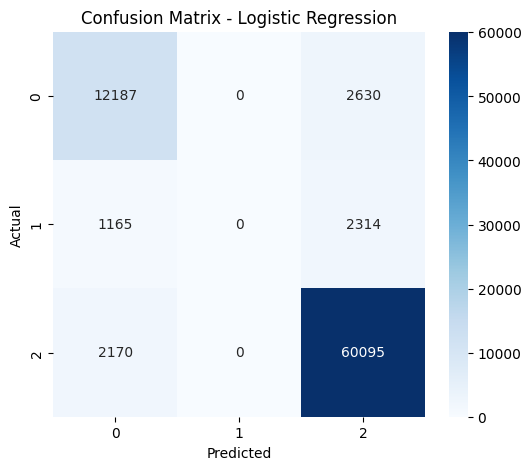

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

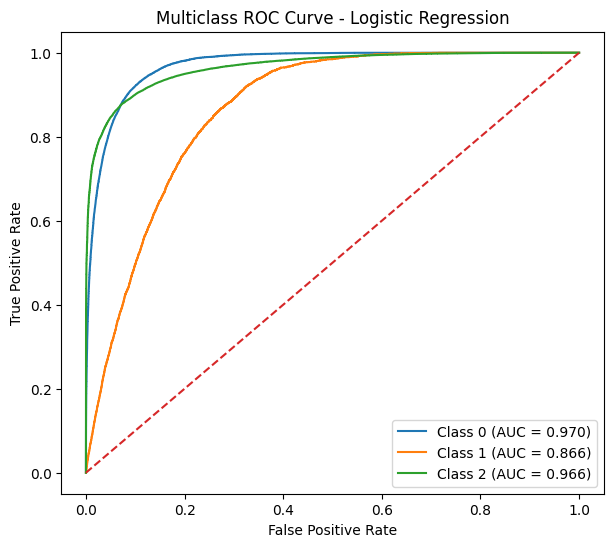

In [27]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Logistic Regression")
plt.legend()
plt.show()

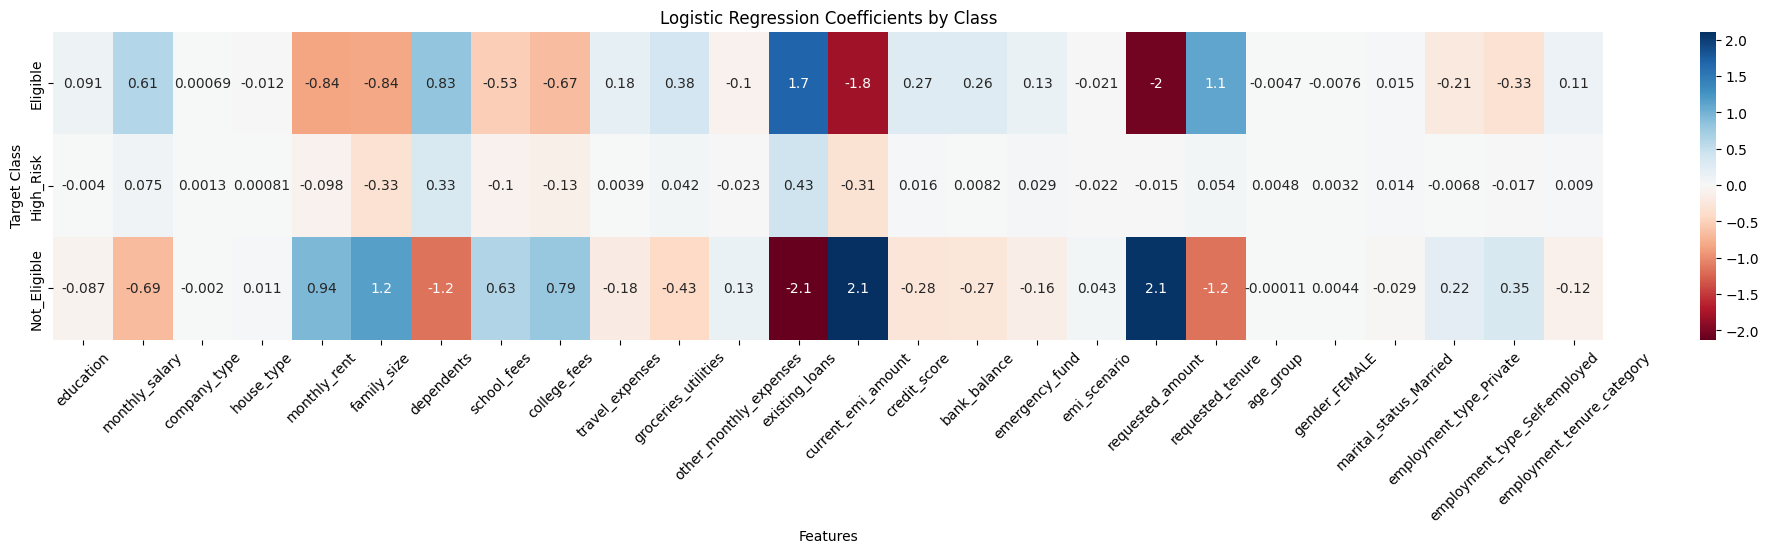

In [28]:
coef_df = pd.DataFrame(
        log_reg_model.coef_,
        columns=X_train.columns,
        index=["Eligible", "High_Risk", "Not_Eligible"]
    )
plt.figure(figsize=(25,4))

# Use a diverging color map (RdBu) so 0 is neutral, 
# Blue is positive correlation, Red is negative.
sns.heatmap(coef_df, annot=True, cmap='RdBu', center=0)

plt.title("Logistic Regression Coefficients by Class")
plt.xlabel("Features")
plt.ylabel("Target Class")
plt.xticks(rotation=45)
plt.show()

In [29]:
import os
os.environ["GIT_PYTHON_REFRESH"] = "quiet"
import mlflow

In [ ]:
mlflow.set_experiment("EMI Eligibility Prediction Logistic Regression Experiment version 1")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
with mlflow.start_run():

    # ---------------------
    # Log Parameters
    # ---------------------
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_param("max_iter", 3000)
    mlflow.log_param("random_state",42)

    # ---------------------
    # Log Metrics
    # ---------------------
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1 score",f1)
    roc_auc_macro = roc_auc_score(
        label_binarize(y_test, classes=[0,1,2]),
        y_pred_prob,
        average="macro"
    )
    mlflow.log_metric("roc_auc_macro", roc_auc_macro)

    # ---------------------
    # Confusion Matrix Plot
    # ---------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    plt.close()

    # ---------------------
    # ROC Curve (Multiclass)
    # ---------------------
    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    plt.figure(figsize=(7,6))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], linestyle='--')
    plt.title("Multiclass ROC Curve")
    plt.legend()

    plt.savefig("roc_curve.png")
    mlflow.log_artifact("roc_curve.png")
    plt.close()

    # ---------------------
    # Coefficient Plot
    # ---------------------
    coef_df = pd.DataFrame(
        log_reg_model.coef_,
        columns=X_test.columns,
        index=["Eligible", "High_Risk", "Not_Eligible"]
    )

    coef_df.T.plot(kind="bar", figsize=(10,6))
    plt.title("Logistic Regression Coefficients")

    plt.savefig("coefficients.png")
    mlflow.log_artifact("coefficients.png")
    plt.close()

    # ---------------------
    # Log Model
    # ---------------------
    mlflow.sklearn.log_model(log_reg_model, "logistic_model")
